In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, JLD2, StatsBase, Distributions, Random
using CSV, CodecZlib
using CairoMakie
using LsqFit, DataStructures

In [167]:
include("./utils.jl")
using .Utils

In [4]:
df = CSV.read("./Data/books_raw/gutenberg_data.csv", DataFrame)
books = df.Text;

In [5]:
all_words = []
for book in books
    if !ismissing(book)
        book = lowercase(book)
        words = filter(!isempty, split(book, r"[^A-Za-z]+"))
        append!(all_words, words)
    end
end

M = length(all_words)
species = unique(all_words)
S = length(species)

sp_map = Dict(w => i for (i,w) in enumerate(species))
all_map = countmap(all_words)
freq_map = Dict(sp_map[k] => v / M for (k,v) in all_map);

In [6]:
STOPWORDS = Set([
    "me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","hey","them","their","theirs","themselves","what","which","who","whom",
    "this","that","these","those","am","is","are","was","were","be","been","being","have","has","had","having","do","does","did",
    "doing","an","the","and","but","if","or","because","as","until","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v", "w","x","y","z"
]);

In [187]:
N = 20000
T = 100
rng = Random.Xoshiro(423)

N_vec = Int.(floor.(rand(rng, Gamma(1.5,2*N), T)))

NULL_MODEL = DataFrame(
        env        = String[],
        species_id = Int[],
        sample_id  = Int[],
        count      = Int[],
        nreads     = Int[]
    )
for t in 1:T
    println(t)
    # N_vec[t] = N
    
    samp = sample(rng, all_words, N_vec[t], replace=false)
    cnt_map = countmap(samp)
    filter!(p -> !(p.first in STOPWORDS), cnt_map)
    for (s, c) in cnt_map
        push!(NULL_MODEL, ("SAMPLE", sp_map[s], t, c, N_vec[t]), promote=true)
    end

    cnt_map = Dict(i => rand(rng, Binomial(N_vec[t], freq_map[i])) for i in 1:S)
    filter!(p -> !(p.first in STOPWORDS), cnt_map)
    for (s, c) in cnt_map
        push!(NULL_MODEL, ("BINOMIAL", s, t, c, N_vec[t]), promote=true)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [188]:
S = 50 # n. of species (the one from the books is huge)
T = 1000 # augment n. of samples as variance is much higer
Nv = Int.(floor.(rand(rng, LogNormal(log(N), 1), T))) # length of books
dispersion = 1 # dispersion parameter
mv = rand(Dirichlet(fill(1.0,S))) # mean word-rates

### FIRST ORDER HETEROGENEITY ###
### Sample Poisson rates ###
λ_mat = [rand(rng, Gamma(dispersion, m/dispersion), T) for m in mv] # real word-rates (each sample has its own real rate)
λ_mat = hcat(λ_mat...)

### Sample word counts and nreads ###
counts = Int.(zeros(T,S))
for i in 1:size(counts, 1)
    for j in 1:size(counts, 2)
        counts[i,j] = rand(rng, Poisson(λ_mat[i,j] * Nv[i]))
    end
end

nreads = sum(counts, dims=2)

### Convert to dataframe ###
for i in 1:size(counts, 1)
    for j in 1:size(counts, 2)
        push!(NULL_MODEL, ("POISSON-GAMMA", j, i, counts[i,j], nreads[i]), promote=true)
    end
end

### SECOND ORDER HETEROGENEITY ###
### Sample Poisson rates ###
α = 4 # coherent solutions for α > 3
χ = (α - 1) / dispersion
θ_mat = [rand(rng, Gamma(α, 1/(χ*m)), T) for m in mv]
θ_mat = hcat(θ_mat...)

### Sample word counts and nreads ###
counts2 = Int.(zeros(T,S))
for i in 1:size(counts2, 1)
    for j in 1:size(counts2, 2)
        λ = rand(rng, Gamma(dispersion, 1/θ_mat[i,j]))
        counts2[i,j] = rand(rng, Poisson(λ * Nv[i]))
    end
end

nreads2 = sum(counts2, dims=2)

### Convert to dataframe ###
for i in 1:size(counts2, 1)
    for j in 1:size(counts2, 2)
        push!(NULL_MODEL, ("POISSON-GAMMA2", j, i, counts2[i,j], nreads2[i]), promote=true)
    end
end

NULL_MODEL = NULL_MODEL[NULL_MODEL.count .!= 0, :]
@save "./Data/processed/null_model.jld2" NULL_MODEL;

In [204]:
println(mv[1])
println(sum(counts[:,1] ./ Nv) / T)
println(sum(counts2[:,1] ./ Nv) / T)

0.09395274052556013
0.09458612397200611
0.09161344497140703


In [190]:
log((dispersion + α - 1) / (dispersion * (α - 2)))

0.6931471805599453

In [205]:
@load "./Data/processed/null_model.jld2" NULL_MODEL

Utils.df_filter!(NULL_MODEL; min_samples=5e1, min_nreads=1e4)

println("--- AFD ---")
out = Utils.compute_AFD(NULL_MODEL; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/AFD/null_afd");

println("--- TL ---")
out = Utils.compute_TL(NULL_MODEL; occ=0.9, bins=30, plot=false, verbose=true, save=true, filename="./Data/TL/null_tl", interpretation=2);

--- AFD ---
SAMPLE
BINOMIAL
POISSON-GAMMA
POISSON-GAMMA2
--- TL ---
SAMPLE
BINOMIAL
POISSON-GAMMA
POISSON-GAMMA2


In [206]:
@load "./Data/AFD/null_afd.jld2" afd_out
null_afd = deepcopy(afd_out)
AFDs = [null_afd]

@load "./Data/TL/null_tl.jld2" taylor_out
null_tl = deepcopy(taylor_out)
TLs = [null_tl];

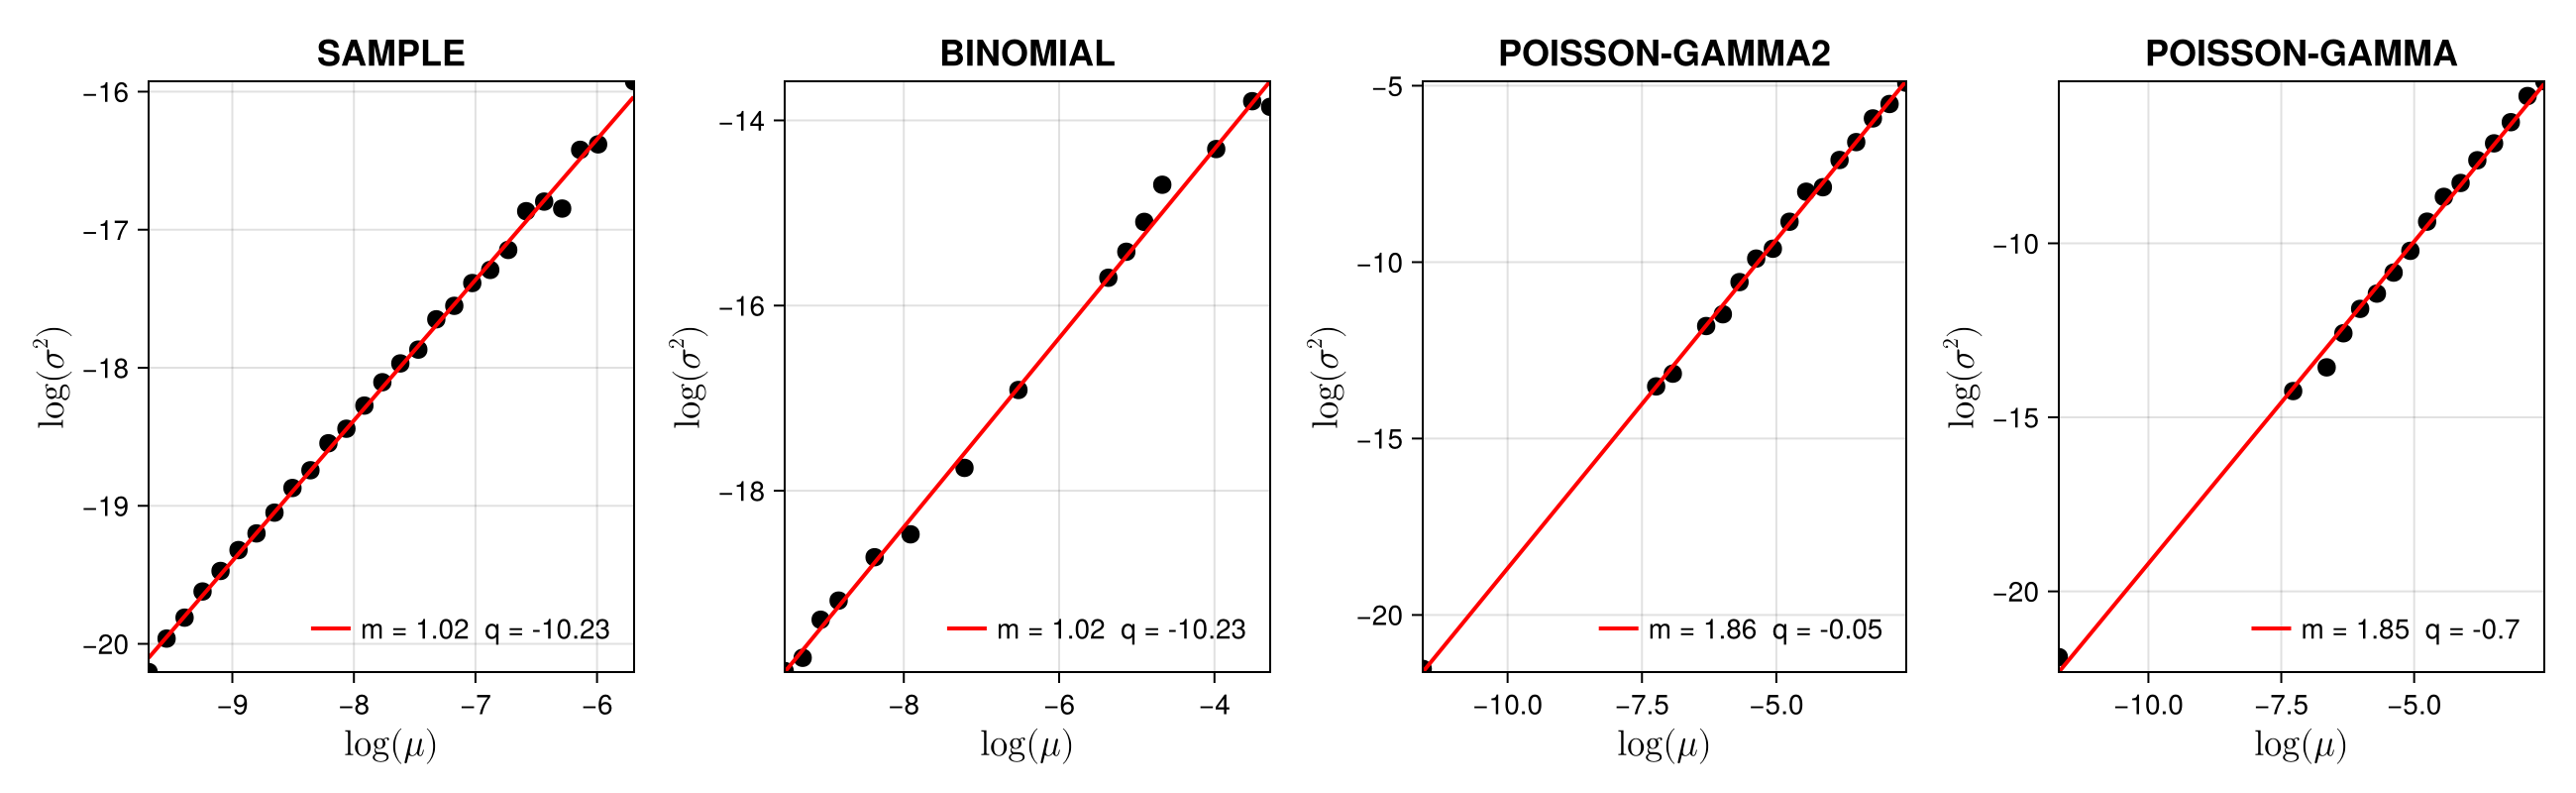

In [207]:
tl_envs = OrderedDict{String, Any}((string(k) => v for tl in TLs for (k, v) in tl))

n = length(keys(tl_envs))

rows = ceil(Int, sqrt(n) - 1)
cols = ceil(Int, n ÷ rows + (n % rows == 0 ? 0 : 1))

fig = Figure(size=(1300, 400))

@. model(x,p) = p[1] + p[2] .* x

intersections = Dict()
for (i, k) in enumerate(keys(tl_envs))
    r = 1 + div(i - 1, cols)
    c = 1 + mod(i - 1, cols)
    ax = Axis(fig[r, c], title = string(k), xlabel=L"\text{log(\mu)}", ylabel=L"\text{log(\sigma^2)}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
    x, y = tl_envs[k]
    mask = .!isnan.(y)

    x = x[mask]
    y = y[mask]

    p0 = [1.5, 2]
    fit = curve_fit(model, x, y, p0)
    p1, p2 = coef(fit)
    intersections[k] = p1

    scatter!(ax, x, y;
          color=:black, markersize=12,
          strokewidth=0.8, strokecolor=:black
            )
    xrange = minimum(x):1e-2:maximum(x)
    lines!(ax, xrange, model(xrange, [p1, p2]);
        color=:red, linewidth=2,
        label="m = $(round(p2, digits=2))  q = $(round(p1, digits=2))")
    axislegend(ax, position=:rb, framevisible=false)
    
    tightlimits!(ax)
end

# save("./Images/TLs.pdf", fig)
fig

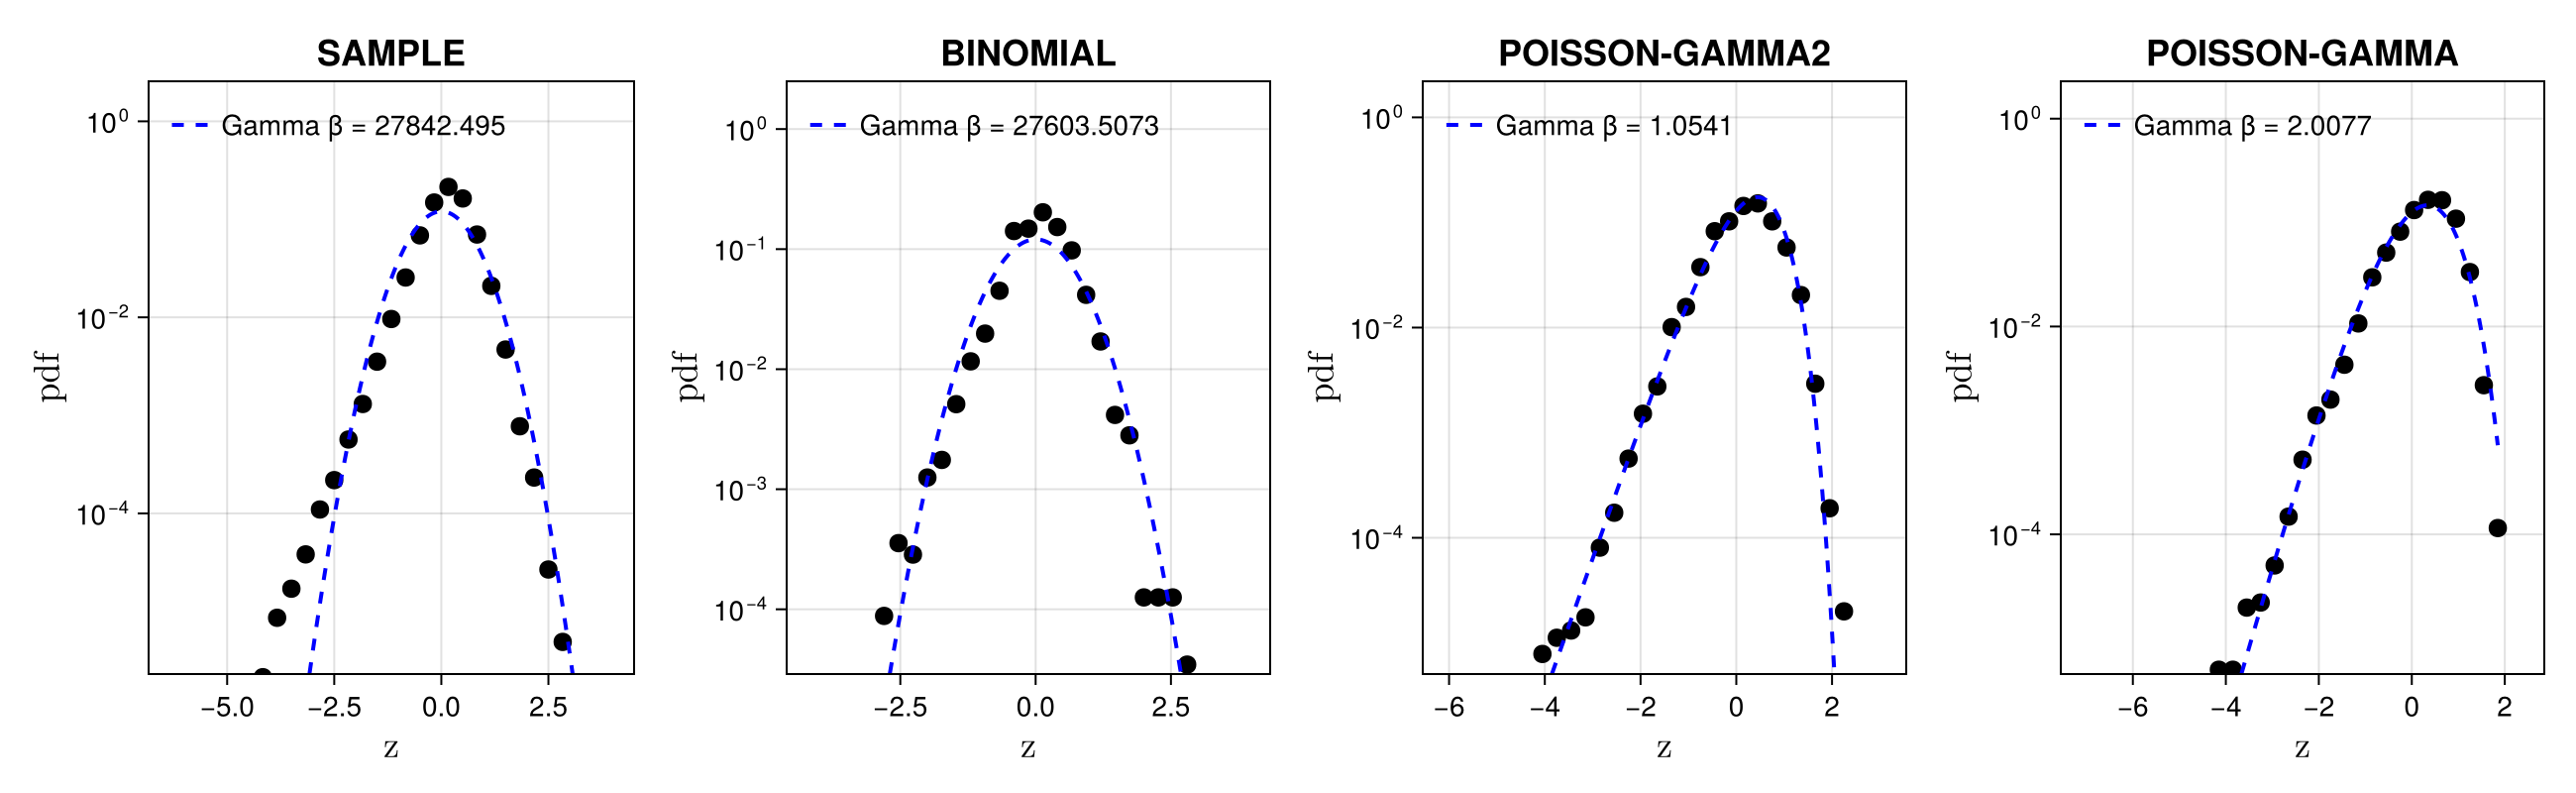

In [208]:
afd_envs = OrderedDict{String, Any}((string(k) => v for afd in AFDs for (k, v) in afd))

n = length(keys(tl_envs))

rows = ceil(Int, sqrt(n) - 1)
cols = ceil(Int, n ÷ rows + (n % rows == 0 ? 0 : 1))

fig = Figure(size=(1300, 400))

for (i, k) in enumerate(keys(tl_envs))
    r = 1 + div(i - 1, cols)
    c = 1 + mod(i - 1, cols)

    x, y = afd_envs[k]
    ax = Axis(fig[r, c], yscale=log10, title = string(k), xlabel=L"\text{z}", ylabel=L"\text{pdf}",
            xlabelsize=18, ylabelsize=18, titlesize=18, limits=((minimum(x)-1,maximum(x)+1), (minimum(y)/100,maximum(y)*5)))

    scatter!(ax, x, 10 .^ log.(y);
          color=:black, markersize=12,
          strokewidth=0.8, strokecolor=:black
            )

    q = intersections[k]
    xrange = minimum(x):1e-2:maximum(x)
    
    β = 2 * exp(q) / (exp(q) - 1)
    if β > 0
        lines!(ax, xrange, 10 .^ Utils.lrl(xrange, β); color=:red, linewidth=2, label="Lomax β = $(round(β, digits=4))")
    end

    β = exp(-q)
    lines!(ax, xrange, 10 .^ Utils.lrg(xrange, β); color=:blue, linestyle=:dash, linewidth=2, label="Gamma β = $(round(β, digits=4))")
    
    axislegend(ax, position=:lt, framevisible=false)
    tightlimits!(ax)
end

# save("./Images/AFDs.pdf", fig)
fig